<a href="https://colab.research.google.com/github/natdebandi/research_migration/blob/main/migratory_flows_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Análisis de las estimaciones de flujos migratorios hacia la Región y Argentina

**Trabajo exploratorio**

Tomado de aqui:
[https://www.pnas.org/doi/epdf/10.1073/pnas.2409418122](https://www.pnas.org/doi/epdf/10.1073/pnas.2409418122)




In [2]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Specify the path to your CSV file in Google Drive
csv_file_path = '/content/drive/MyDrive/1. Investigacion/1.working documents/Movilidad regional NAT/data/international_migration_flow.csv'

# Read the CSV file into a pandas DataFrame
try:
    df = pd.read_csv(csv_file_path)
    print("CSV file successfully loaded.")
    # Display the first 5 rows of the DataFrame
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file was not found at {csv_file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

CSV file successfully loaded.


,country_from,country_to,migration_month,num_migrants
0,AD,AE,2019-01,12
1,AD,AE,2019-02,2
2,AD,AE,2019-03,1
3,AD,AE,2019-04,7
4,AD,AE,2019-05,0


In [4]:
# Extract the year from the 'migration_month' column
df['year'] = pd.to_datetime(df['migration_month']).dt.year

# Group by country_from, country_to, and year, and sum num_migrants
grouped_df = df.groupby(['country_from', 'country_to', 'year'])['num_migrants'].sum().reset_index()

# Display the result
display(grouped_df.head())

,country_from,country_to,year,num_migrants
0,AD,AE,2019,58
1,AD,AE,2020,30
2,AD,AE,2021,24
3,AD,AE,2022,40
4,AD,AF,2019,16


In [5]:
%pip install pycountry

In [6]:
import pycountry

# Function to get country name from alpha_2 code
def get_country_name(alpha_2_code):
    try:
        return pycountry.countries.get(alpha_2=alpha_2_code).name
    except AttributeError:
        return None

# Add the 'country_name_from' and 'country_name_to' columns
grouped_df['country_name_from'] = grouped_df['country_from'].apply(get_country_name)
grouped_df['country_name_to'] = grouped_df['country_to'].apply(get_country_name)

# Display the updated DataFrame
display(grouped_df.head())

,country_from,country_to,year,num_migrants,country_name_from,country_name_to
0,AD,AE,2019,58,Andorra,United Arab Emirates
1,AD,AE,2020,30,Andorra,United Arab Emirates
2,AD,AE,2021,24,Andorra,United Arab Emirates
3,AD,AE,2022,40,Andorra,United Arab Emirates
4,AD,AF,2019,16,Andorra,Afghanistan


Reviso datos de Argentina

In [7]:
# Filter for migrants arriving in Argentina
migrants_to_argentina = grouped_df[grouped_df['country_to'] == 'AR']

# Group by year and sum the number of migrants arriving in Argentina
migrants_to_argentina_yearly = migrants_to_argentina.groupby('year')['num_migrants'].sum().reset_index()

print("Migrants arriving in Argentina per year:")
display(migrants_to_argentina_yearly)



Migrants arriving in Argentina per year:


,year,num_migrants
0,2019,181018
1,2020,112938
2,2021,87422
3,2022,161746


In [8]:
# Filter for migrants leaving Argentina
migrants_from_argentina = grouped_df[grouped_df['country_from'] == 'AR']

# Group by year and sum the number of migrants leaving Argentina
migrants_from_argentina_yearly = migrants_from_argentina.groupby('year')['num_migrants'].sum().reset_index()

print("\nMigrants leaving Argentina per year:")
display(migrants_from_argentina_yearly)


Migrants leaving Argentina per year:


,year,num_migrants
0,2019,233110
1,2020,147791
2,2021,181612
3,2022,215598


In [9]:
# Merge the two dataframes on the 'year' column
migration_argentina_yearly = pd.merge(migrants_to_argentina_yearly, migrants_from_argentina_yearly, on='year', suffixes=('_to_AR', '_from_AR'))

# Rename the columns for clarity
migration_argentina_yearly.rename(columns={'num_migrants_to_AR': 'Migrants to Argentina', 'num_migrants_from_AR': 'Migrants from Argentina'}, inplace=True)

# Display the combined dataframe
print("Combined yearly migration data for Argentina:")
display(migration_argentina_yearly)

Combined yearly migration data for Argentina:


,year,Migrants to Argentina,Migrants from Argentina
0,2019,181018,233110
1,2020,112938,147791
2,2021,87422,181612
3,2022,161746,215598


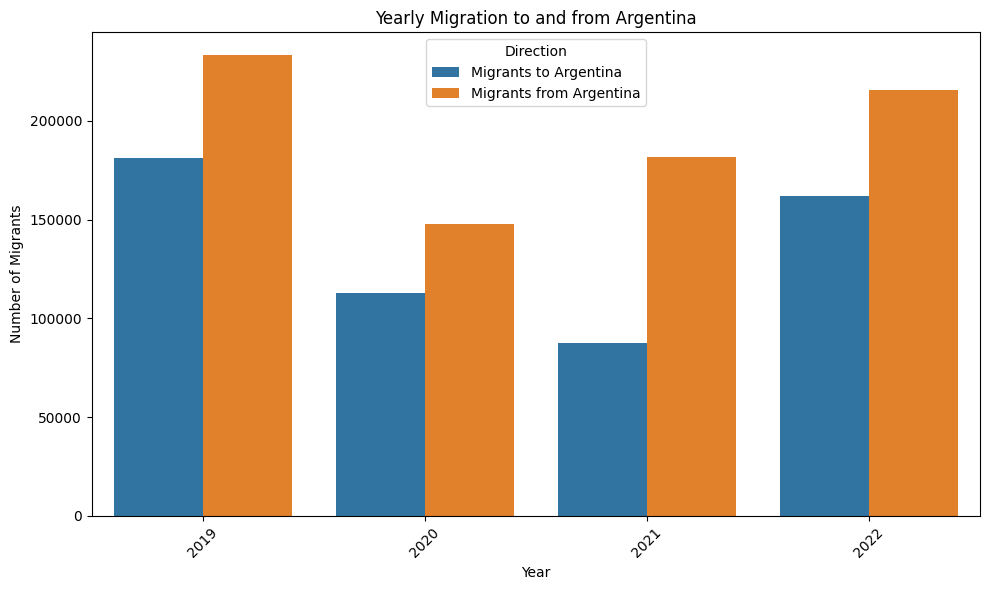

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape the dataframe for plotting
migration_argentina_melted = migration_argentina_yearly.melt('year', var_name='Direction', value_name='Number of Migrants')

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='year', y='Number of Migrants', hue='Direction', data=migration_argentina_melted)
plt.title('Yearly Migration to and from Argentina')
plt.xlabel('Year')
plt.ylabel('Number of Migrants')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Migración hacia los paíse de la Región

(selección de paises)

In [11]:
# Define the list of target countries (using their Alpha-2 codes)
target_countries = ['AR','CO', 'CL', 'BR', 'PE', 'EC']
#target_countries = ['AR','CO', 'CL', 'BR', 'PE', 'UY', 'EC', 'BO', 'PY']
# Filter for migrants arriving in the target countries
migrants_to_region = grouped_df[grouped_df['country_to'].isin(target_countries)]

# Group by country_to and year, and sum the number of migrants arriving in each country
migrants_to_region_yearly_country = migrants_to_region.groupby(['country_to', 'year'])['num_migrants'].sum().reset_index()



([<matplotlib.axis.XTick at 0x7a28a3f15910>,
 [Text(2019, 0, '2019'),
  Text(2020, 0, '2020'),
  Text(2021, 0, '2021'),
  Text(2022, 0, '2022')])

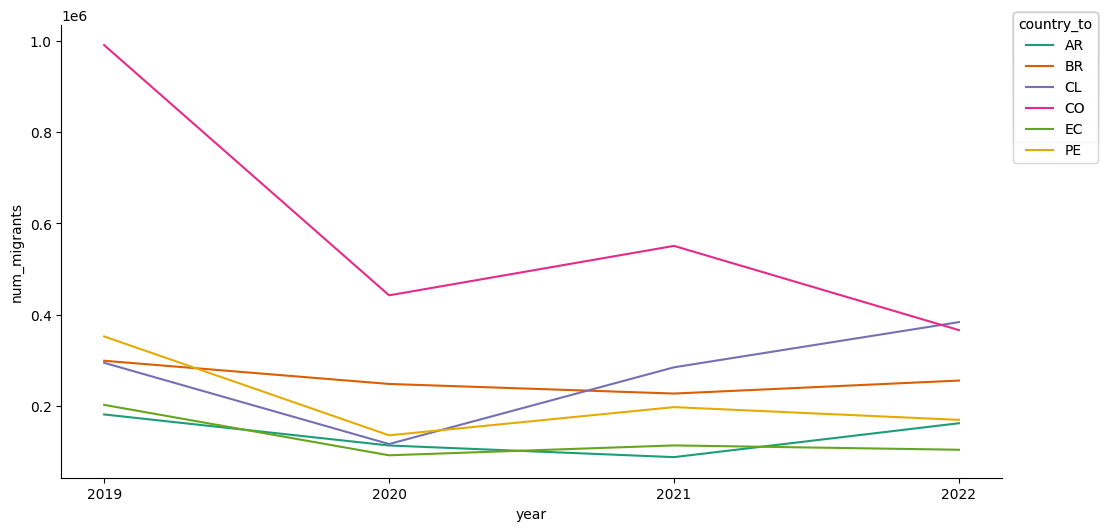

In [12]:
from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['year']
  ys = series['num_migrants']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = migrants_to_region_yearly_country.sort_values('year', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('country_to')):
  _plot_series(series, series_name, i)
  fig.legend(title='country_to', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('year')
_ = plt.ylabel('num_migrants')

# Set x-axis ticks to display only the years
plt.xticks(df_sorted['year'].unique())

Emigración desde los paises de la región


In [15]:
# Define the list of target countries (using their Alpha-2 codes)

target_countries = ['AR','CO', 'CL', 'BR', 'PE', 'EC']
#target_countries = ['AR','CO', 'CL', 'BR', 'PE', 'UY', 'EC', 'BO', 'PY']

# Filter for migrants arriving in the target countries
migrants_from_region = grouped_df[grouped_df['country_from'].isin(target_countries)]

# Group by country_to and year, and sum the number of migrants arriving in each country
migrants_from_region_yearly_country = migrants_from_region.groupby(['country_from', 'year'])['num_migrants'].sum().reset_index()

print("Emigrants from each specified South American country per year:")
display(migrants_from_region_yearly_country)

Emigrants from each specified South American country per year:


,country_from,year,num_migrants
0,AR,2019,233110
1,AR,2020,147791
2,AR,2021,181612
3,AR,2022,215598
4,BR,2019,487238
5,BR,2020,222421
6,BR,2021,275419
7,BR,2022,547888
8,CL,2019,126237
9,CL,2020,105123


([<matplotlib.axis.XTick at 0x7a28a1d72510>,
 [Text(2019, 0, '2019'),
  Text(2020, 0, '2020'),
  Text(2021, 0, '2021'),
  Text(2022, 0, '2022')])

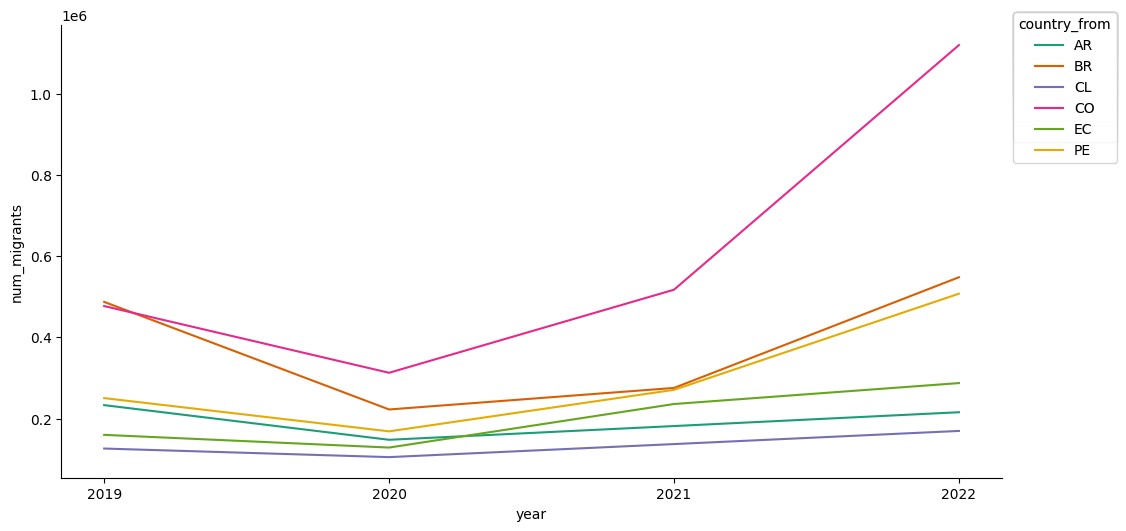

In [16]:
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['year']
  ys = series['num_migrants']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = migrants_from_region_yearly_country.sort_values('year', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('country_from')):
  _plot_series(series, series_name, i)
  fig.legend(title='country_from', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('year')
_ = plt.ylabel('num_migrants')

# Set x-axis ticks to display only the years
plt.xticks(df_sorted['year'].unique())